###Rdkit

There are Python libraries that are made for working just with chemical data. One commonly used library in Python for data science (or cheminformatics) is called RDKit. RDKit is an open-source cheminformatics library.

RDKit provides a molecule object that allows you to manipulate chemical structures. It has capabilities for reading and writing molecular file formats, calculating molecular properties, and performing substructure searches. In addition, it offers a wide range of cheminformatics algorithms such as molecular fingerprint generation, similarity metrics calculation, and molecular descriptor computation


###Creating molecule with SMILES

In [1]:
from rdkit import Chem

In [2]:
methane = Chem.MolFromSmiles("C")
ethane = Chem.MolFromSmiles("CC")
propane = Chem.MolFromSmiles("CCC")
ethene = Chem.MolFromSmiles("C=C")
cyclohexane = Chem.MolFromSmiles("C1CCCCC1")
benzene = Chem.MolFromSmiles("c1ccccc1")
acetic_acid = Chem.MolFromSmiles("CC(=O)O")
ethyne = Chem.MolFromSmiles("C#C")

###Working with RDkit molecules

The next cell has settings for modifying drawing molecules. It adds labels of atom indices and sets the image size.

In [3]:
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem import Draw

#configuration for displaying in jupter notebook
IPythonConsole.iPython_useSVG = True # use SVG for high quality images
IPythonConsole.drawOptions.addAtomIndices = True #show aton indices
IPythonConsole.molSize = 250,250 #show image size

In [4]:
acetic_acid_atoms = acetic_acid.GetAtoms()
print(acetic_acid_atoms)

In [5]:
len(acetic_acid_atoms)

4

In [6]:
atom = acetic_acid_atoms[1]
atom

we can print the atom element or atom hybridization.

In [7]:
print(atom.GetSymbol())
print(atom.GetHybridization())

C
SP2


We can use a for loop to give information about each atom

In [8]:
for atom in acetic_acid_atoms:
    print(f" {atom.GetSymbol()} has Hybridization {atom.GetHybridization()}")

 C has Hybridization SP3
 C has Hybridization SP2
 O has Hybridization SP2
 O has Hybridization SP2


In [9]:
acetic_acid_bonds = acetic_acid.GetBonds()
bond = acetic_acid_bonds[0]
bond.GetBondType()

rdkit.Chem.rdchem.BondType.SINGLE

Use a for loop to print information about each bond. For each bond, you should
print the starting atom symbol, the ending atom symbol, and the bond type.

In [10]:
for bond in acetic_acid.GetBonds():
    print(f"Bond between {bond.GetBeginAtom().GetSymbol()} and {bond.GetEndAtom().GetSymbol()} is a {bond.GetBondType().name} bond.")

Bond between C and C is a SINGLE bond.
Bond between C and O is a DOUBLE bond.
Bond between C and O is a SINGLE bond.


###Editing Atoms with RDKit

RDKit to change our molecule structure. Let's consider benzene for our example. We will change one of the carbons in the benzene ring to a nitrogen to make pyridine. creating a copy of our benzene molecule using another function from RDKit called RWMol. RWMol makes our molecule readable and writeable (or "editable").

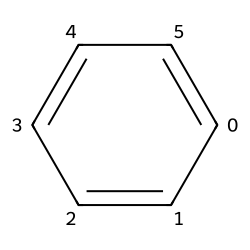

In [11]:
pyridine = Chem.RWMol(benzene)
pyridine

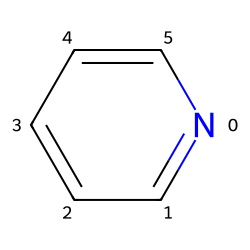

In [12]:
atom = pyridine.GetAtomWithIdx(0) #Get atom with index 0 mentioned above
atom.SetAtomicNum(7) #set atomic num to 7
pyridine

sets aromaticity fo molecule

In [13]:
#Chem.SanitizeMol(pyridine) # Reruns Aromaticity perception
Chem.MolToSmiles(pyridine) # kekule structure
#pyridine # give structure

'c1ccncc1'

Change another atom in the pyridine ring to create pyrimidine.

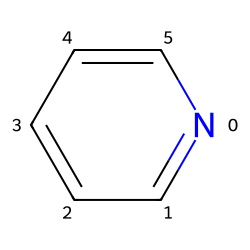

In [14]:
pyrimidine = Chem.RWMol(pyridine)
pyrimidine

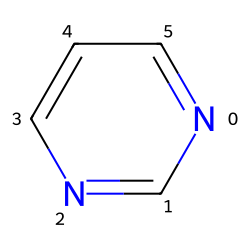

In [15]:
atom = pyrimidine.GetAtomWithIdx(2)
atom.SetAtomicNum(7)
pyrimidine

In [16]:
Chem.MolToSmiles(pyrimidine)

'c1cncnc1'

Combining with molecules

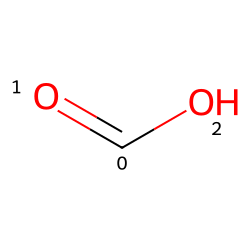

In [17]:
carboxyl = Chem.MolFromSmiles("C(=O)O")
carboxyl

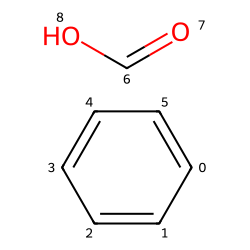

In [18]:
combined = Chem.CombineMols(benzene, carboxyl)
combined

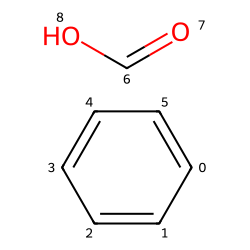

In [19]:
editable_mol = Chem.RWMol(combined)
editable_mol

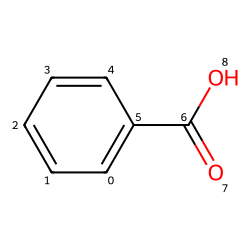

In [20]:
editable_mol.AddBond(5, 6, order=Chem.rdchem.BondType.SINGLE)
editable_mol

###Molecular Sanitization

When a molecule is loaded into RDKit, a "molecular sanitization" step typically takes place. Molecular sanitization ensures that molecules are "reasonable":that they can be represented with octet-complete Lewis dot structures.

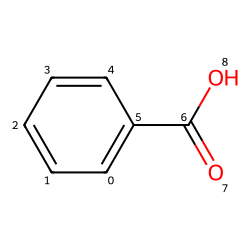

In [21]:
Chem.SanitizeMol(editable_mol)
editable_mol

Protein phoshorylation refers to the additon of a phosphate group to the -OH group of an amino acid and occurs for serine, threonine, or tyrosine residues.
tyrosine = Chem.MolFromSmiles("C1=CC(=CC=C1CC(C(=O)O)N)O")
tyrosine = Chem.RWMol(tyrosine)
tyrosine

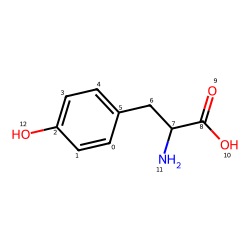

In [22]:
tyrosine = Chem.MolFromSmiles("C1=CC(=CC=C1CC(C(=O)O)N)O")
tyrosine

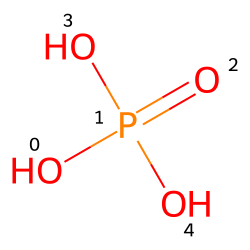

In [23]:
# Create phosphate group
phosphate = Chem.MolFromSmiles("OP(=O)(O)O")
phosphate

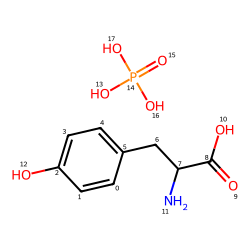

In [24]:
combined = Chem.CombineMols(tyrosine, phosphate)
combined

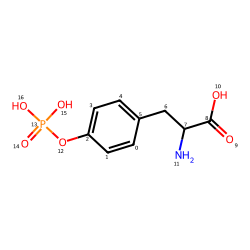

In [25]:
# Make editable, add bond between phenol O (12) and P (14), remove extra OH (13)
phospho_tyrosine = Chem.RWMol(combined)
phospho_tyrosine.AddBond(12, 14, order=Chem.rdchem.BondType.SINGLE)
phospho_tyrosine.RemoveAtom(13)  # Remove one OH from phosphate
Chem.SanitizeMol(phospho_tyrosine)
phospho_tyrosine